In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv('../03_telco-churn/telco-churn.csv')
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [3]:
df.columns = df.columns.str.lower()

In [4]:
categorical_columns = df.select_dtypes(include='string').columns.to_list()
df[categorical_columns] = df[categorical_columns].apply(lambda x: x.str.lower().str.replace(' ', '_', regex=False))

In [5]:
df['totalcharges'] = df['totalcharges'].apply(pd.to_numeric, errors='coerce')
df['seniorcitizen'] = df['seniorcitizen'].astype('str')

In [6]:
df['totalcharges'] = df['totalcharges'].fillna(0)

In [7]:
df['churn'] = (df.churn == 'yes').astype('int')

In [8]:
from sklearn.model_selection import train_test_split

df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=1)

y_train = df_train.churn
y_val = df_val.churn
y_test = df_test.churn

In [9]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [10]:
numerical_columns = df_train_full.columns[(df_train_full.dtypes=='float') | (df_train_full.dtypes=='int')].tolist()
numerical_columns.remove('churn')

categorical_columns = df_train_full.columns[df_train_full.dtypes=='str'].tolist()
categorical_columns.remove('customerid')

In [11]:
y_train_full = df_train_full.churn.values
df_train_one_hot_encoded = pd.get_dummies(df_train_full[categorical_columns], dtype=int)
df_train_full = pd.concat([df_train_full[numerical_columns], df_train_one_hot_encoded], axis=1)

df_train_one_hot_encoded = pd.get_dummies(df_train[categorical_columns], dtype=int)
df_train = pd.concat([df_train[numerical_columns], df_train_one_hot_encoded], axis=1)

df_val_one_hot_encoded = pd.get_dummies(df_val[categorical_columns], dtype=int)
df_val = pd.concat([df_val[numerical_columns], df_val_one_hot_encoded], axis=1)

df_test_one_hot_encoded = pd.get_dummies(df_test[categorical_columns], dtype=int)
df_test = pd.concat([df_test[numerical_columns], df_test_one_hot_encoded], axis=1)

In [12]:
y_train_full.sum()

np.int64(1521)

In [13]:
from sklearn.linear_model import LogisticRegression

model_full = LogisticRegression()
model_full.fit(df_train_full, y_train_full)

/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
y_pred_val = model_full.predict(df_val)

In [15]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, y_pred_val) # accuracy score is misleading when there is class imbalance

0.8055358410220014

In [16]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)
precdicted_positive = (y_pred_val == 1)
precdicted_negative = (y_pred_val == 0)

In [17]:
tp = (actual_positive & precdicted_positive).sum()
tn = (actual_negative & precdicted_negative).sum()
fp = (actual_negative & precdicted_positive).sum()
fn = (actual_positive & precdicted_negative).sum()

In [18]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix

array([[920, 103],
       [171, 215]])

In [19]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
accuracy

np.float64(0.8055358410220014)

In [20]:
precision = tp / (tp + fp) #out of all the predicted positives, how many were actual positives
precision

np.float64(0.6761006289308176)

In [21]:
recall = tp / (tp + fn) #how many positives are correctly identified
recall

np.float64(0.5569948186528497)

In [22]:
true_positive_rate = tp / (tp + fn)
false_positive_rate = fp / (fp + tn)
print(true_positive_rate, false_positive_rate)

0.5569948186528497 0.10068426197458455


In [23]:
y_pred_val_prob = model_full.predict_proba(df_val)[:, 1]
y_pred_val_prob

array([0.01026883, 0.19880196, 0.20249386, ..., 0.13296137, 0.82718479,
       0.84258676], shape=(1409,))

In [24]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_val_prob)

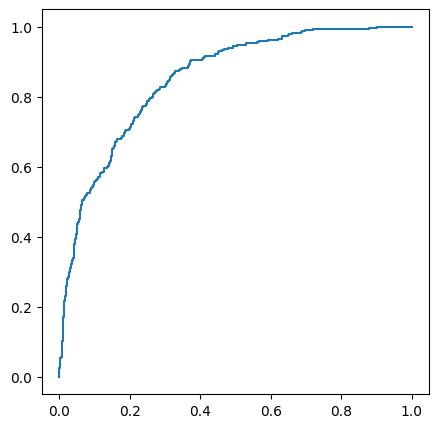

In [25]:
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr)

In [26]:
from sklearn.metrics import auc

auc(fpr, tpr)

0.8517390181271176

In [27]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_val, y_pred_val_prob)

0.8517390181271176

In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

scores = cross_val_score(model_full, df_train_full, y_train_full, cv=cv, scoring='roc_auc')

/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-

In [29]:
print(scores)
print(scores.mean())
print(scores.std())

[0.83913155 0.84249297 0.84971742 0.83357265 0.83814749]
0.8406124146274744
0.005371491344904595
